# GRM with PyMC — simulated dataset


## Model

$$
P(u_{ij} \geq k \mid \theta_i, a_j, b_{jk}) = \sigma\!\left(a_j(\theta_i - b_{jk})\right)
$$

Priors: $\theta_i \sim \mathcal{N}(0,1)$, $a_j \sim \text{LogNormal}(0, 0.5)$, $b_{jk} \sim \mathcal{N}(0,1.5)$ (ordered per item).

In [43]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import nest_asyncio
nest_asyncio.apply()

## Data

In [44]:
rng = np.random.default_rng(42)

N = 1000  # respondents
J = 20   # items total

# K per item
K_per_item = np.array([3] * 10 + [4] * 5 + [5] * 5)

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
# b_true[j]: sorted array of K_j-1 thresholds
b_true = [np.sort(rng.normal(0, 1, K_per_item[j] - 1)) for j in range(J)]

# Generate responses
Y = np.zeros((N, J), dtype=int)
for j in range(J):
    K_j = K_per_item[j]
    # P*(Y >= k) for k=1,...,K_j-1 — shape (N, K_j-1)
    eta = a_true[j] * (theta_true[:, None] - b_true[j][None, :])
    cum_p = 1 / (1 + np.exp(-eta))
    probs = np.concatenate([
        1 - cum_p[:, :1],
        cum_p[:, :-1] - cum_p[:, 1:],
        cum_p[:, -1:],
    ], axis=1)  # (N, K_j)
    u = rng.uniform(size=(N, 1))
    Y[:, j] = (u > np.cumsum(probs, axis=1)).sum(axis=1)

print(f"Response matrix shape: {Y.shape}")
for k in np.unique(K_per_item):
    items_k = np.where(K_per_item == k)[0]
    counts = np.bincount(Y[:, items_k].ravel(), minlength=k)
    print(f"K={k}: {len(items_k)} items, category counts = {counts}")

Response matrix shape: (1000, 20)
K=3: 10 items, category counts = [4299 1880 3821]
K=4: 5 items, category counts = [1710  589  799 1902]
K=5: 5 items, category counts = [1838  254  403  799 1706]


In [45]:
df = pd.DataFrame(Y,
                  index=[f"person_{i+1}" for i in range(Y.shape[0])],
                  columns=[f"item_{j+1}" for j in range(Y.shape[1])])

df.tail()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,item_11,item_12,item_13,item_14,item_15,item_16,item_17,item_18,item_19,item_20
person_996,2,2,0,2,2,0,0,2,1,0,3,3,1,3,0,2,3,0,3,0
person_997,2,0,2,1,2,2,1,0,1,2,3,3,3,2,0,4,0,4,3,4
person_998,2,2,2,1,0,1,2,1,2,0,0,2,0,0,2,0,2,3,3,4
person_999,0,0,2,2,0,0,1,2,2,0,0,3,2,2,3,0,3,4,3,4
person_1000,0,2,2,2,2,0,2,2,1,0,0,2,3,3,3,3,4,1,0,4


In [46]:
df.to_csv("./data.csv", index=False)

## Preprocessing

In [47]:
# df_long = pd.melt(
#     df.reset_index(),
#     id_vars="index",
#     var_name="item",
#     value_name="response",
# ).rename(columns={"index": "person"})

# item_categories = df.columns
# df_long["person"] = pd.Categorical(df_long["person"], categories=df.index, ordered=True)
# df_long["item"] = pd.Categorical(df_long["item"], categories=item_categories, ordered=True)

# df_long.head()

In [48]:
# import numpy as np
# import pymc as pm

# person_idx = df_long["person"].cat.codes.to_numpy()
# persons = df_long["person"].cat.categories.to_numpy()
# item_idx = df_long["item"].cat.codes.to_numpy()
# items = df_long["item"].cat.categories.to_numpy()
# responses = df_long["response"].to_numpy().astype("int64")

# K = int(responses.max() + 1)
# n_thresholds = K - 1

# coords = {
#     "person": persons,
#     "item": items,
#     "threshold": np.arange(n_thresholds),
#     "obs_id": np.arange(len(df_long)),
# }


## PyMC


In [49]:
df = pd.read_csv("./data.csv")

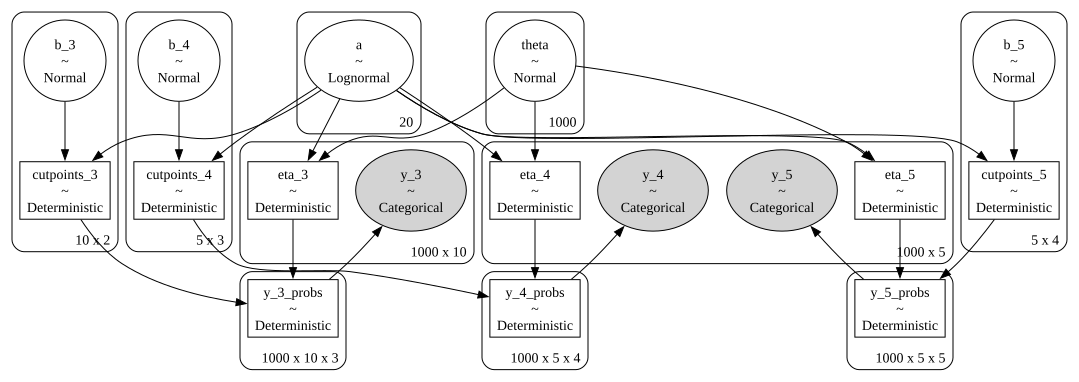

In [50]:
K_per_item = df.max() + 1
unique_K = np.sort(np.unique(K_per_item))

with pm.Model() as grm_mixed:
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, shape=N)
    a = pm.LogNormal("a", mu=0.0, sigma=0.5, shape=J)

    for k in unique_K:
        item_idx = np.where(K_per_item == k)[0]
        J_k = len(item_idx)
        Y_k = Y[:, item_idx]  # (N, J_k)
        b_k = pm.Normal(
            f"b_{k}",
            mu=0.0,
            sigma=1.5,
            shape=(J_k, k - 1),
            transform=pm.distributions.transforms.ordered,
            initval=np.tile(np.linspace(-1.0, 1.0, k - 1), (J_k, 1)),
        )

        eta_k = pm.Deterministic(f"eta_{k}",theta[:, None] * a[item_idx][None, :])   # (N, J_k)
        cutpoints_k = pm.Deterministic(f"cutpoints_{k}", a[item_idx][:, None] * b_k)  # (J_k, K-1)

        pm.OrderedLogistic(
            f"y_{k}",
            eta=eta_k,
            cutpoints=cutpoints_k,
            observed=Y_k,
        )

pm.model_to_graphviz(grm_mixed)

In [51]:
# g = pm.model_to_graphviz(grm_mixed)

# for k in unique_K:
#     with g.subgraph() as s:
#         s.attr(rank="same")
#         s.node(f"eta_{k}")
#         s.node(f"cutpoints_{k}")

# g

In [52]:
with grm_mixed:
    idata = pm.sample(
        draws=3000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
        nuts_sampler="numpyro",
    )


Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/5000 [00:01<?, ?it/s]




Running chain 0:   5%|▌         | 250/5000 [00:07<01:51, 42.44it/s]


Running chain 0:  15%|█▌        | 750/5000 [00:13<01:00, 70.11it/s]




Running chain 0:  25%|██▌       | 1250/5000 [00:18<00:47, 79.26it/s]


Running chain 0:  30%|███       | 1500/5000 [00:21<00:42, 81.69it/s]


Running chain 0:  35%|███▌      | 1750/5000 [00:24<00:39, 82.64it/s]


Running chain 0:  40%|████      | 2000/5000 [00:27<00:36, 82.88it/s]


Running chain 0:  45%|████▌     | 2250/5000 [00:30<00:33, 82.93it/s]


Running chain 0:  50%|█████     | 2500/5000 [00:33<00:30, 83.02it/s]


Running chain 0:  55%|█████▌    | 2750/5000 [00:36<00:26, 83.43it/s]


Running chain 0:  60%|██████    | 3000/5000 [00:39<00:23, 83.56it/s]


Running chain 0:  65%|██████▌   | 3250/5000 [00:42<00:20, 83.62it/s]


Running chain 0:  70%|███████   | 3500/5000 [00:45<00:17, 83.83it/s]


Running chain 0:  75%|████

In [53]:
summary = az.summary(
    idata,
    var_names=["a", "theta"] + [f"b_{k}" for k in unique_K],
    round_to=3,
)
bad = summary.query("r_hat > 1.01").copy()
bad["kind"] = bad.index.to_series().str.extract(r"^([a-zA-Z_]+)")[0]
bad.groupby("kind")["r_hat"].agg(["count", "max", "mean"])

,count,max,mean
kind,,,


In [54]:
item_params = pd.DataFrame({"item": df.columns})
item_params["a"] = idata.posterior["a"].mean(dim=["chain", "draw"]).values  # (J,)

for k in K_per_item.unique():
    b_col = f"b_{k}"
    B_k = idata.posterior[b_col].mean(dim=["chain", "draw"]).values
    J_k = B_k.shape[1]
    B_df = pd.DataFrame(B_k, columns=[f"b{i+1}" for i in range(J_k)])
    for col in B_df.columns:
        item_params.loc[np.array(k == K_per_item), col] = B_df[col].values

item_params    


,item,a,b1,b2,b3,b4
0,item_1,0.979535,0.359001,0.394151,NaN,NaN
1,item_2,0.641605,0.500885,0.728962,NaN,NaN
2,item_3,0.935287,-1.770013,-0.243315,NaN,NaN
3,item_4,1.349563,-2.090684,0.075886,NaN,NaN
4,item_5,1.011206,0.063927,1.139509,NaN,NaN
5,item_6,1.194416,0.325879,1.221340,NaN,NaN
6,item_7,1.386875,-0.560349,0.501260,NaN,NaN
7,item_8,0.807108,-0.550343,-0.092283,NaN,NaN
8,item_9,1.346048,-0.607876,1.141643,NaN,NaN
9,item_10,1.261331,0.621021,0.781982,NaN,NaN


In [55]:
import os
os.makedirs("./results", exist_ok=True)

item_params.to_csv("./results/pymc_params.csv", index=False)
print("Saved to ./results/pymc_params.csv")


Saved to ./results/pymc_params.csv


In [56]:
theta_mean = idata.posterior["theta"].mean(dim=["chain", "draw"]).values  # (N,)
theta_df = pd.DataFrame({"person": np.arange(N), "theta": theta_mean})
display(theta_df.head())

theta_df.to_csv("./results/pymc_theta.csv", index=False)
print("Saved to ./results/pymc_theta.csv")

,person,theta
0,0,0.144398
1,1,-1.384982
2,2,0.771042
3,3,1.480037
4,4,-1.782994


Saved to ./results/pymc_theta.csv
